# PEL 309 - Data Science - Paper

Esse arquivo contém as análises e experimentos correspondentes ao trabalho da matéria PEL 309.

In [1]:
import os
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, train_test_split

/home/melo/code/data-science/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("zahranusratt/smartphone-usage-and-addiction-analysis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/melo/.cache/kagglehub/datasets/zahranusratt/smartphone-usage-and-addiction-analysis-dataset/versions/1


In [3]:
df = pd.read_csv(f"{path}/{os.listdir(path)[0]}")

## Droping duplicates

In [4]:
df = df.drop_duplicates()

df.shape, df.columns, df.dtypes

((7500, 16),
 Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
        'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
        'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
        'stress_level', 'academic_work_impact', 'addiction_level',
        'addicted_label'],
       dtype='str'),
 transaction_id                 str
 user_id                        str
 age                          int64
 gender                         str
 daily_screen_time_hours    float64
 social_media_hours         float64
 gaming_hours               float64
 work_study_hours           float64
 sleep_hours                float64
 notifications_per_day        int64
 app_opens_per_day            int64
 weekend_screen_time        float64
 stress_level                   str
 academic_work_impact           str
 addiction_level                str
 addicted_label               int64
 dtype: object)

In [5]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## Removing Unused/Bad Columns

In [6]:
# If there is one entry per user, feel free to remove the column, it is not a series
if df['user_id'].nunique() == df.shape[0]:
    print("One entry per user")
    df = df.drop(columns=['transaction_id', 'user_id', 'addiction_level'])
else:
    print("More than one entry per user")
    df = df.drop(columns=['transaction_id', 'addiction_level'])

One entry per user


In [7]:
df.columns, df.dtypes

(Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
        'gaming_hours', 'work_study_hours', 'sleep_hours',
        'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
        'stress_level', 'academic_work_impact', 'addicted_label'],
       dtype='str'),
 age                          int64
 gender                         str
 daily_screen_time_hours    float64
 social_media_hours         float64
 gaming_hours               float64
 work_study_hours           float64
 sleep_hours                float64
 notifications_per_day        int64
 app_opens_per_day            int64
 weekend_screen_time        float64
 stress_level                   str
 academic_work_impact           str
 addicted_label               int64
 dtype: object)

In [8]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


## Testing and converting categorical variables

In [9]:
# Converting categorical columns to categorical data type
for column in ["gender", "stress_level", "academic_work_impact"]:
    print(df[column].value_counts())
    df[column] = df[column].astype("category")

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64


In [37]:
targets = df["addicted_label"]

features_df = df.drop(columns=["addicted_label"])

features_df.dtypes, targets.shape

(age                           int64
 gender                     category
 daily_screen_time_hours     float64
 social_media_hours          float64
 gaming_hours                float64
 work_study_hours            float64
 sleep_hours                 float64
 notifications_per_day         int64
 app_opens_per_day             int64
 weekend_screen_time         float64
 stress_level               category
 academic_work_impact       category
 dtype: object,
 (7500,))

In [43]:
X_train, X_test, y_train, y_test = train_test_split(features_df, targets, test_size=.2, random_state=42)

In [44]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6000, 12), (1500, 12), (6000,), (1500,))

In [45]:
y_train.value_counts(), y_test.value_counts()

(addicted_label
 1    4264
 0    1736
 Name: count, dtype: int64,
 addicted_label
 1    1044
 0     456
 Name: count, dtype: int64)

# Preprocessing + Classification Pipelines

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [47]:
X_train.select_dtypes(include=['number']).head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
4664,28,4.90,1.92,3.41,1.19,5.90,153,122,6.70
4411,22,4.70,4.14,0.33,4.57,5.51,98,90,6.76
7448,29,8.13,1.83,3.11,3.29,6.29,236,138,8.79
1919,27,5.48,2.72,1.10,0.65,5.24,82,104,6.14
1298,29,7.90,1.31,2.64,1.01,6.98,166,111,9.26


In [48]:
# separating categorical data from numeric and encoding using dummy encoding (one hot) in the pipeline

X_train.select_dtypes(include=['category']).head()

,gender,stress_level,academic_work_impact
4664,Male,High,Yes
4411,Female,High,No
7448,Male,High,No
1919,Female,Medium,No
1298,Male,High,Yes


In [49]:
numeric_features = X_train.select_dtypes(include=['number']).columns
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_features = X_train.select_dtypes(include=['category']).columns
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selector(dtype_exclude="category")),
        ("cat", categorical_transformer, selector(dtype_include="category")),
    ]
)

In [50]:
classifiers = {
    "LogisticRegression": LogisticRegression(),
    "MLPClassifier": MLPClassifier(),
    "RandomForestClassifier": RandomForestClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "XGBClassifier": XGBClassifier()
}

In [51]:
results = []

for key, clf_model in classifiers.items():
    clf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf_model)
        ]
    )
    clf.fit(X_train, y_train)
    y_hat = clf.predict(X_test)
    
    results.append({
        "clf_name": key,
        "clf": clf,
        "confusion_matrix": confusion_matrix(y_test, y_hat),
        "accuracy_score": accuracy_score(y_test, y_hat),
        "f1_score": f1_score(y_test, y_hat),
        "precision_score": precision_score(y_test, y_hat),
        "recall_score": recall_score(y_test, y_hat)

    })

/home/melo/code/data-science/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [52]:
results_df = pd.DataFrame(results).drop(columns=[ "clf"])

results_df

,clf_name,confusion_matrix,accuracy_score,f1_score,precision_score,recall_score
0,LogisticRegression,"[[372, 84], [76, 968]]",0.893333,0.923664,0.920152,0.927203
1,MLPClassifier,"[[395, 61], [61, 983]]",0.918667,0.941571,0.941571,0.941571
2,RandomForestClassifier,"[[411, 45], [63, 981]]",0.928000,0.947826,0.956140,0.939655
3,GradientBoostingClassifier,"[[426, 30], [63, 981]]",0.938000,0.954745,0.970326,0.939655
4,XGBClassifier,"[[406, 50], [57, 987]]",0.928667,0.948582,0.951784,0.945402


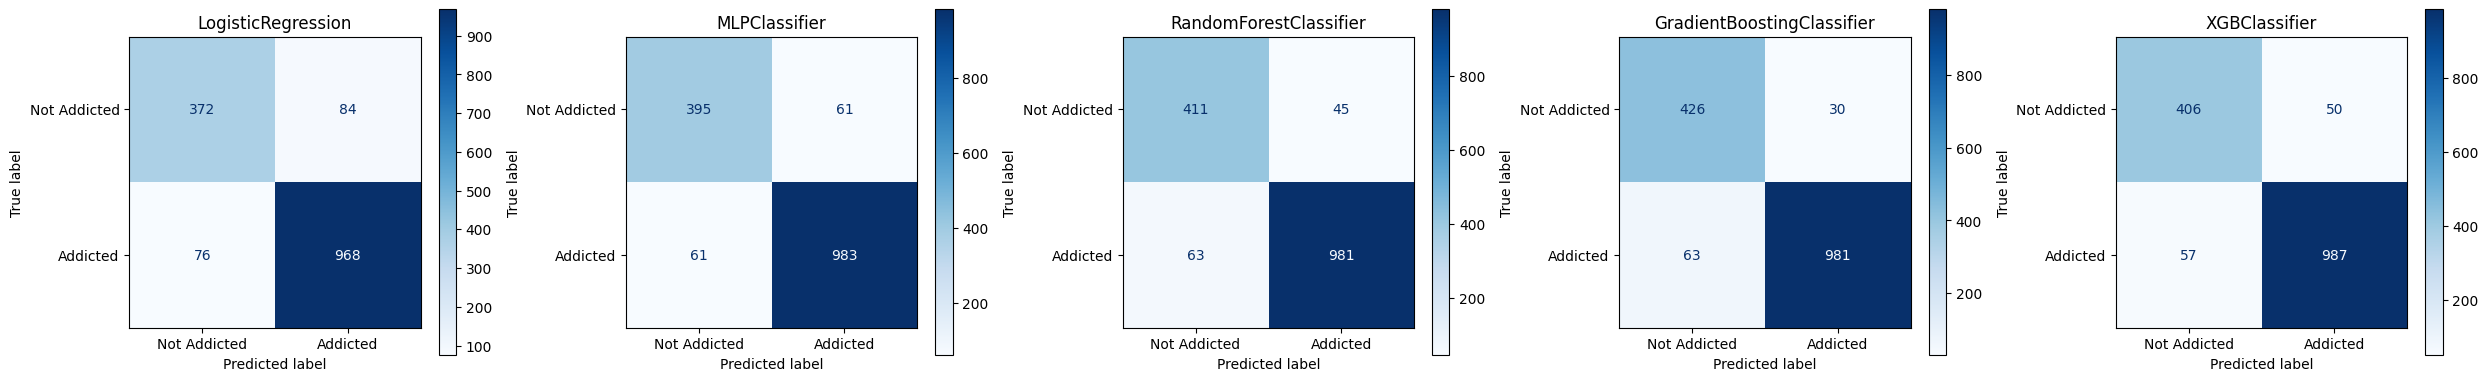

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt

rows = 2
columns = 3

f, axes = plt.subplots(1, 5, figsize=(25, 4))

for i in range(len(results_df["confusion_matrix"])):

    ConfusionMatrixDisplay(confusion_matrix=results_df["confusion_matrix"][i], display_labels=["Not Addicted", "Addicted"]).plot(ax=axes[i], cmap="Blues")
    axes[i].title.set_text(results_df["clf_name"][i])
    plt.tight_layout()
